In [1]:
import glob, json, pickle, scipy.io, os
import numpy as np
import mat73
import matplotlib.pyplot as plt
from tqdm import tqdm
import itertools
from statsmodels.stats.multitest import fdrcorrection
import seaborn as sns
import pandas as pd
from scipy.stats import ttest_rel

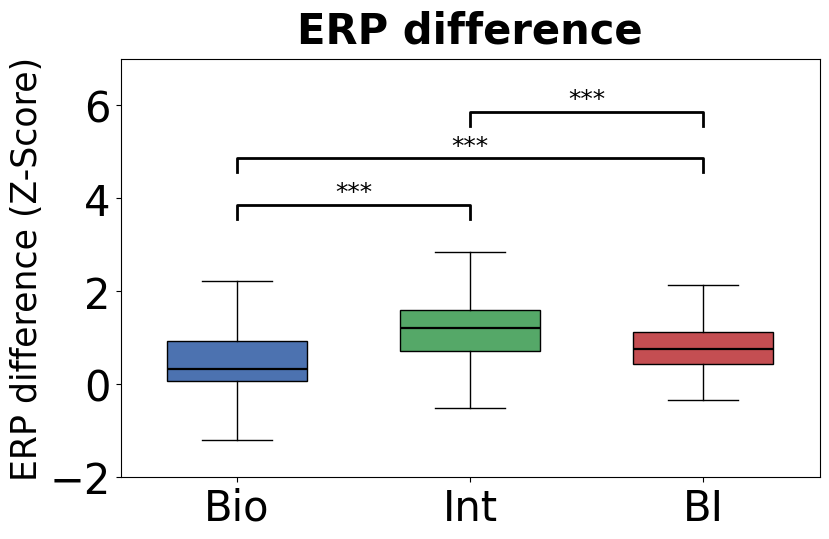

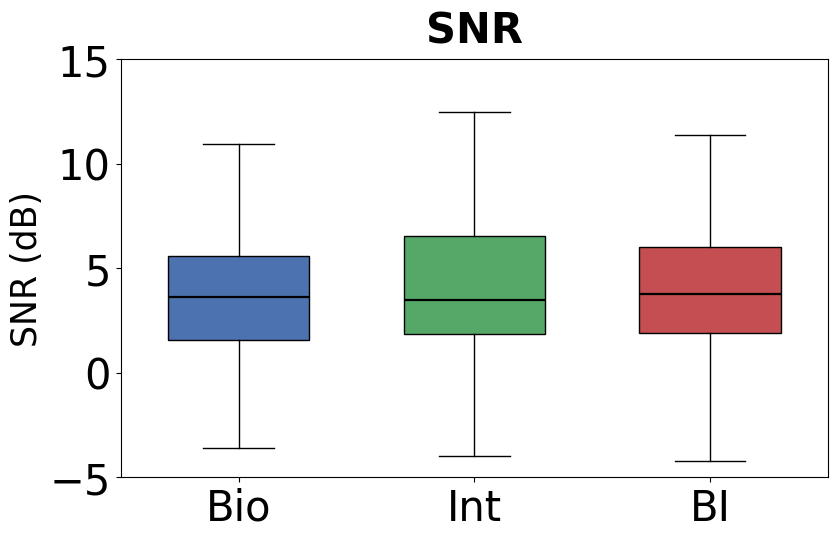

In [35]:
# ------------------------------------------------------------
# Load results
# ------------------------------------------------------------
fPath = "/Users/woojaejeong/Desktop/Data/USC/DARPA-NEAT/Code/Modeling/Data/"
res_file = fPath + "Results/QualityTest_results_post.pkl"

with open(res_file, "rb") as f:
    results = pickle.load(f)

TOI_list = ["Bio", "Int", "BI_h"]


def add_sig_star(ax, x1, x2, y, h=0.3, text="*", fontsize=18):
    """Draws a line with stars between two bars at x1 and x2 on a single axis."""
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=2, c="black")

    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", fontsize=fontsize)


# ------------------------------------------------------------
# Plot metric
# ------------------------------------------------------------


def plot_metric(metric_name, ax):

    all_vals = [results[metric_name][toi]["values"] for toi in TOI_list]
    x = np.arange(len(TOI_list))

    colors = [
        "#4C72B0",  # Bio
        "#55A868",  # Int
        "#C44E52",  # BI_h
    ]

    # Boxplots
    for i, vals in enumerate(all_vals):
        ax.boxplot(
            [vals],
            positions=[x[i]],
            widths=0.6,
            showfliers=False,
            patch_artist=True,
            boxprops=dict(facecolor=colors[i], edgecolor="black"),
            medianprops=dict(color="black", linewidth=1.6),
        )

    # Text placement
    global_max = np.max([np.max(v) for v in all_vals])
    global_min = np.min([np.min(v) for v in all_vals])
    height = global_max - global_min
    ylim_bottom = global_min - 0.12 * height
    ylim_top = global_max + 0.2 * height

    ax.set_ylim(ylim_bottom, ylim_top)
    ax.set_xticks(x)
    ax.set_xticklabels(["Bio", "Int", "BI"], fontsize=30)
    ax.grid(False)
    ax.tick_params(axis="y", labelsize=30)
    plt.tight_layout()


# ------------------------------------------------------------
# Plot ERP and SNR
# ------------------------------------------------------------

# ERP_diff plot
fig, ax = plt.subplots(figsize=(8, 5))
plot_metric("ERP_diff", ax)

vals = [results["ERP_diff"][toi]["values"] for toi in TOI_list]
global_max = np.max([np.max(v) for v in vals])
global_min = np.min([np.min(v) for v in vals])

y0 = global_max

add_sig_star(ax, 0, 1, y0, text="***")  # Bio vs Int
add_sig_star(ax, 0, 2, y0 + 1, text="***")  # Bio vs BI_h
add_sig_star(ax, 1, 2, y0 + 2, text="***")  # Int vs BI_h

plt.ylabel("ERP difference (Z-Score)", fontsize=25)
plt.title("ERP difference", fontsize=30, fontweight="bold", pad=12)
plt.ylim([-2, 7])
plt.show()

# SNR plot
fig, ax = plt.subplots(figsize=(8, 5))
plot_metric("SNR", ax)
plt.ylabel("SNR (dB)", fontsize=25)
plt.title("SNR", fontsize=30, fontweight="bold", pad=12)
plt.ylim([-5, 15])
plt.show()

In [ ]:
# Report values
# Load saved results
fPath = "/Users/woojaejeong/Desktop/Data/USC/DARPA-NEAT/Code/Modeling/Data/Results/"
res_file = fPath + "QualityTest_results_post.pkl"

with open(res_file, "rb") as f:
    results = pickle.load(f)

TOI_list = ["Bio", "Int", "BI_h"]

# ------------------------------------------------------------
# Report summary
# ------------------------------------------------------------

print("=== ERP_diff Summary (mean ± SEM) ===")
for toi in TOI_list:
    mean_val = results["ERP_diff"][toi]["mean"]
    sem_val = results["ERP_diff"][toi]["sem"]
    print(f"{toi:5s}: {mean_val:.4f} ± {sem_val:.4f}")

print("\n=== SNR Summary (mean ± SEM) ===")
for toi in TOI_list:
    mean_val = results["SNR"][toi]["mean"]
    sem_val = results["SNR"][toi]["sem"]
    print(f"{toi:5s}: {mean_val:.4f} ± {sem_val:.4f}")

=== ERP_diff Summary (mean ± SEM) ===
Int  : 0.5096 ± 0.0428
wBI  : 0.4026 ± 0.0334
wBI_12: 0.4020 ± 0.0329

=== SNR Summary (mean ± SEM) ===
Int  : 4.4133 ± 0.2209
wBI  : 4.2537 ± 0.2171
wBI_12: 4.2465 ± 0.2179


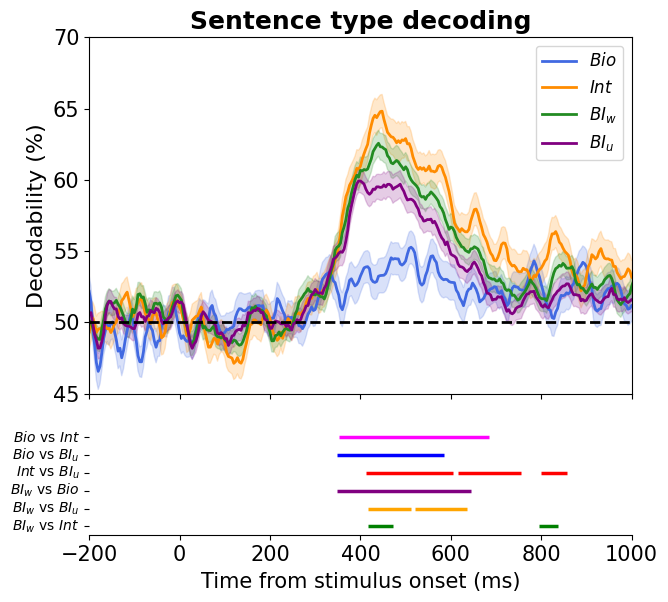

In [3]:
# =========================================================
# Load data
# =========================================================
fPath = "/Users/woojaejeong/Desktop/Data/USC/DARPA-NEAT/Code/Modeling/Data/"

with open(fPath + "Results/svmDecode_Bio.pkl", "rb") as file:
    decodeBio = pickle.load(file)["decodeScore"] * 100

with open(fPath + "Results/svmDecode_Int.pkl", "rb") as file:
    decodeInt = pickle.load(file)["decodeScore"] * 100

with open(fPath + "Results/svmDecode_wBI_h.pkl", "rb") as file:
    decodeBI = pickle.load(file)["decodeScore"] * 100

with open(fPath + "Results/svmDecode_BI_h.pkl", "rb") as file:
    decodeBI_h = pickle.load(file)["decodeScore"] * 100

sigTime = mat73.loadmat(fPath + "Results/sigTime.mat")

sig_IB = sigTime["sigTime_IB"].astype(int)
if np.sum(sig_IB.shape) < 3:
    sig_IB = sig_IB.reshape(1, 2)

sig_BIB = sigTime["sigTime_BIB"].astype(int)
if np.sum(sig_BIB.shape) < 3:
    sig_BIB = sig_BIB.reshape(1, 2)

sig_IBI = sigTime["sigTime_IBI"].astype(int)
if np.sum(sig_IBI.shape) < 3:
    sig_IBI = sig_IBI.reshape(1, 2)

sig_wBIBI = sigTime["sigTime_wBIBI"].astype(int)
if np.sum(sig_wBIBI.shape) < 3:
    sig_wBIBI = sig_wBIBI.reshape(1, 2)

sig_wBIB = sigTime["sigTime_wBIB"].astype(int)
if np.sum(sig_wBIB.shape) < 3:
    sig_wBIB = sig_wBIB.reshape(1, 2)

sig_IwBI = sigTime["sigTime_IwBI"].astype(int)
if np.sum(sig_IwBI.shape) < 3:
    sig_IwBI = sig_IwBI.reshape(1, 2)

# =========================================================
# Time vector
# =========================================================
t = np.arange(-200, 1500, 4)

# =========================================================
# Create figure
# =========================================================
fig, (ax_main, ax_sig) = plt.subplots(
    2,
    1,
    figsize=(7, 6),
    gridspec_kw={"height_ratios": [4, 1.2]},  # tighter significance panel
    sharex=True,
)


# =========================================================
# Main decoding plot
# =========================================================
def plot_decoding(ax, data, color, label):
    m = np.mean(data, axis=0)
    err = np.std(data, axis=0) / np.sqrt(data.shape[0])
    ax.plot(t, m, color=color, linewidth=2, label=label)
    ax.fill_between(t, m - err, m + err, color=color, alpha=0.2)


plot_decoding(ax_main, decodeBio, "royalblue", r"$Bio$")
plot_decoding(ax_main, decodeInt, "darkorange", r"$Int$")
plot_decoding(ax_main, decodeBI, "forestgreen", r"$BI_w$")
plot_decoding(ax_main, decodeBI_h, "purple", r"$BI_u$")

ax_main.axhline(50, linestyle="--", color="k", linewidth=2)
ax_main.set_ylabel("Decodability (%)", fontsize=16)
ax_main.set_title("Sentence type decoding", fontsize=18, fontweight="bold")
ax_main.legend(fontsize=12, loc="upper right")
ax_main.set_xlim(-200, 1000)
ax_main.set_ylim(45, 70)
ax_main.tick_params(labelsize=15)

# =========================================================
# Significance lines
# =========================================================
sig_labels = [
    r"$BI_w$ vs $Int$",
    r"$BI_w$ vs $BI_u$",
    r"$BI_w$ vs $Bio$",
    r"$Int$ vs $BI_u$",
    r"$Bio$ vs $BI_u$",
    r"$Bio$ vs $Int$",
]
sig_colors = ["green", "orange", "purple", "red", "blue", "magenta"]
sig_arrays = [sig_IwBI, sig_wBIBI, sig_wBIB, sig_IBI, sig_BIB, sig_IB]

n_sig = len(sig_labels)
ax_sig.set_ylim(-0.5, n_sig - 0.5)
ax_sig.set_yticks(range(n_sig))
ax_sig.set_yticklabels(sig_labels, fontsize=10, va="center")
ax_sig.set_xlabel("Time from stimulus onset (ms)", fontsize=15, labelpad=5)
ax_sig.tick_params(axis="x", labelsize=15)
ax_sig.spines["top"].set_visible(False)
ax_sig.spines["right"].set_visible(False)
ax_sig.spines["left"].set_visible(False)
ax_sig.spines["bottom"].set_visible(True)
ax_sig.set_xlim(-200, 1000)

# Plot thin significance lines
for j, (sig, color) in enumerate(zip(sig_arrays, sig_colors)):
    for i in range(sig.shape[0]):
        ax_sig.hlines(
            y=j,
            xmin=t[sig[i, 0]],
            xmax=t[sig[i, 1]],
            colors=color,
            linewidth=2.5,
        )

# =========================================================
# Layout adjustments for compact figure
# =========================================================
plt.subplots_adjust(hspace=0.15, bottom=0.1, top=0.93)
plt.show()

In [24]:
# ============================================================
# Load results
# ============================================================
with open(
    "/Users/woojaejeong/Desktop/Data/USC/DARPA-NEAT/Code/Modeling/Data/Results/ablation_summary_ML_rw.pkl",
    "rb",
) as file:
    results = pickle.load(file)

toi = "rwBI_16"
Model = ["svm", "knn"]
n_subj = 137  # subjects count

# ============================================================
# Compute mean ± SE for paired (train == test)
# ============================================================
paired_means = []
for model in Model:
    if model in results[toi]:
        v = np.array(results[toi][model])
        mean_val = np.mean(v)
        se_val = np.std(v, ddof=1) / np.sqrt(n_subj)
        paired_means.append(f"{mean_val:.4f} ± {se_val:.4f}")
    else:
        paired_means.append("-")

# ============================================================
# Create DataFrame for display
# ============================================================
df = pd.DataFrame({"Condition": Model, "Mean ± SE": paired_means})

pd.set_option("display.width", 120)
pd.set_option("display.colheader_justify", "center")

print("\n=== Results — Mean ± SE ===\n")
print(df.to_string(index=False))


=== Results — Mean ± SE ===

Condition    Mean ± SE   
   svm    0.6400 ± 0.0112
   knn    0.6293 ± 0.0107


In [9]:
# ============================================================
# Load results
# ============================================================

# TOI = [
#     "Bio",
#     "Int",
#     "BI_h",
#     "wBI_h",
#     "rwBI_h",
#     "BI",
#     "wBI",
#     "rwBI",
#     "BI_12",
#     "wBI_12",
#     "rwBI_12",
# ]

TOI = ["BI_16", "wBI_16", "rwBI_16"]
model = "eegnet"
n_subj = 137  # subjects count

# ============================================================
# Compute mean ± SE
# ============================================================
paired_means = []
for toi in TOI:
    with open(
        f"/Users/woojaejeong/Desktop/Data/USC/DARPA-NEAT/Code/Modeling/Data/Results/{model}_{toi}_ablation.pkl",
        "rb",
    ) as file:
        v = pickle.load(file)["decodeScore"]
        mean_val = np.mean(v)
        se_val = np.std(v, ddof=1) / np.sqrt(n_subj)
        paired_means.append(f"{mean_val:.4f} ± {se_val:.4f}")


# ============================================================
# Create DataFrame for display
# ============================================================
df = pd.DataFrame({"Condition": TOI, "Mean ± SE": paired_means})

pd.set_option("display.width", 120)
pd.set_option("display.colheader_justify", "center")

print("\n=== Results — Mean ± SE ===\n")
print(df.to_string(index=False))


=== Results — Mean ± SE ===

Condition    Mean ± SE   
   BI_16  0.6894 ± 0.0092
  wBI_16  0.7071 ± 0.0095
 rwBI_16  0.6822 ± 0.0090


In [4]:
# ============================================================
# Load results
# ============================================================

TOI_Train = ["Bio", "Int", "BI_16", "wBI_16"]
TOI_Test = ["Bio", "Int", "BI_16", "wBI_16"]

model = "deepconvnet"
n_subj = 137  # number of subjects
results_dir = (
    "/Users/woojaejeong/Desktop/Data/USC/DARPA-NEAT/Code/Modeling/Data/Results/"
)

# ============================================================
# Compute mean ± SE for each (Train, Test) pair
# ============================================================
records = []

for train in TOI_Train:
    for test in TOI_Test:
        file_path = os.path.join(results_dir, f"{model}_{train}_{test}_ablation.pkl")

        if not os.path.exists(file_path):
            print(f"⚠️ Missing file: {file_path}")
            continue

        with open(file_path, "rb") as file:
            data = pickle.load(file)

        decode_scores = np.array(data["decodeScore"])
        mean_val = np.mean(decode_scores)
        se_val = np.std(decode_scores, ddof=1) / np.sqrt(n_subj)
        records.append(
            {
                "Train": train,
                "Test": test,
                "Mean": mean_val,
                "SE": se_val,
                "Mean ± SE": f"{mean_val:.4f} ± {se_val:.4f}",
            }
        )

# ============================================================
# Create and display summary table
# ============================================================
df = pd.DataFrame(records, columns=["Train", "Test", "Mean ± SE"])

pd.set_option("display.width", 140)
pd.set_option("display.colheader_justify", "center")

print("\n=== Results — Mean ± SE ===\n")
print(df.to_string(index=False))


=== Results — Mean ± SE ===

Train   Test     Mean ± SE   
   Bio    Bio 0.5832 ± 0.0111
   Bio    Int 0.6309 ± 0.0109
   Bio  BI_16 0.6401 ± 0.0114
   Bio wBI_16 0.6474 ± 0.0117
   Int    Bio 0.6079 ± 0.0092
   Int    Int 0.6867 ± 0.0105
   Int  BI_16 0.6836 ± 0.0098
   Int wBI_16 0.7122 ± 0.0102
 BI_16    Bio 0.6051 ± 0.0105
 BI_16    Int 0.6846 ± 0.0107
 BI_16  BI_16 0.6834 ± 0.0103
 BI_16 wBI_16 0.7114 ± 0.0099
wBI_16    Bio 0.6065 ± 0.0098
wBI_16    Int 0.7024 ± 0.0104
wBI_16  BI_16 0.6871 ± 0.0105
wBI_16 wBI_16 0.7125 ± 0.0103
